# System

```JSON
"config":{"run":"vqe","nqubits":7,"state":"dmatrix","output":{"file_name_prefix":"xy_ansatz_time_depol_tmax_20_p1e-1","draw":{"status":false,"fig_dpi":100,"type":"png"}},"observable":{"def":"ising","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5],"bn":[1.0,1.0,1.0,1.0,1.0,1.0,1.0],"r":1}},"ansatz":{"layer":30,"gateset":1,"ugate":{"type":"xy-iss","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5],"bn":[0,0,0,0,0,0,0],"r":0},"time":{"min":0.0,"max":20}}},"vqe":{"iteration":10,"optimization":{"status":true,"algorithm":"SLSQP","constraint":true}},"init_param":{"value":"random"},"noise_profile":{"status":true,"type":"time-depol","noise_prob":[0,0,<VARY THIS PARAM>,0.0],"noise_on_init_param":{"status":false,"value":0}},"redundant":{"identity_factors":[[0,0,0,0],[1,1,1,1]]},"zne":{"method":"richardson","degree":1,"sampling":"default","data_points":null}}
```

# Import

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
"font.family":      "serif",
"mathtext.fontset": "dejavuserif",
"axes.linewidth":   0.8,
"xtick.direction":  "in",
"ytick.direction":  "in",
"xtick.top":        True,
"ytick.right":      True,
"xtick.major.size": 4,
"ytick.major.size": 4,
"xtick.minor.size": 2,
"ytick.minor.size": 2,
"xtick.minor.visible": True,
"ytick.minor.visible": True,
"xtick.labelsize":  8,   # ✓ already here
"ytick.labelsize":  8,   # ✓ already here
"axes.labelsize":   8,   # ← add this (xlabel / ylabel)
"legend.fontsize":  8,   # ← add this (legend text)
"font.size":        8,   # ← add this (global fallback)
})

# Variables

In [3]:
# Usage
BASE_DIR = "data/7Q-various-gamma"

EXACT_SOL: float = -8.566772233505624

width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
MASTER_EXPORT_DIR = "../master-reports/"

---
# Raw Data Processing Before Plotting

In [4]:
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
RAW_SIM_DATA.keys()

dict_keys(['p1e-4', 'p1e-1', 'p1e-3', 'p1e-2', 'p1e-5'])

In [5]:
RAW_SIM_DATA.keys()

dict_keys(['p1e-4', 'p1e-1', 'p1e-3', 'p1e-2', 'p1e-5'])

In [6]:
import re

def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}
    # Access the 'data' folder from your experiment tree
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        processed[exp_name] = {}

        # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
        nf_folder = content.get("VQE_noiseoff", {})
        nf_costs = []
        for k, run in nf_folder.items():
            if run and "REDUNDANT" not in k and "output" in run:
                try:
                    nf_costs.append(run["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError):
                    continue

        nf_stats = {
            "mean": float(np.mean(nf_costs)) if nf_costs else None,
            "std":  float(np.std(nf_costs)) if nf_costs else None
        }

        # --- 2. Processing ZNE Subfolders (ric1, ric2, ..., ricN -> order N) ---
        zne_folder = content.get("ZNE", {})

        for label, runs in zne_folder.items():
            # Order is derived directly from the label name: ricN -> order N
            # Expected number of noise points for order N is N+1
            m = re.search(r"ric(\d+)", label)
            expected_order = int(m.group(1)) if m else None
            expected_len = expected_order + 1 if expected_order is not None else None

            ext_vals, all_y_curves = [], []
            noise_levels = None

            for k, run in runs.items():
                # Skip nulls or redundant files
                if not run or "REDUNDANT" in k or "output" not in run:
                    continue

                # Safely navigate the nested structure
                zne_vals = run["output"].get("zne_values", {})
                others = zne_vals.get("others", {})

                tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                p_list = run["config"]["noise_profile"]["noise_prob"]
                # Fallback logic: check 'others' first, then 'zne_values' directly
                current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
                current_n = others.get("sorted_noise") or zne_vals.get("sorted_noise")
                ext_val = zne_vals.get("extrapolated_value")

                if not (current_y and current_n and ext_val is not None):
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing required keys.")
                    continue

                # Validate against the label's expected order (not the first-seen run)
                if expected_len is not None and len(current_n) != expected_len:
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: curve length "
                          f"{len(current_n)} != expected {expected_len} for order {expected_order}")
                    continue

                # Guard against y/noise length mismatch within the same run
                if len(current_y) != len(current_n):
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: y/noise length mismatch "
                          f"({len(current_y)} vs {len(current_n)})")
                    continue

                if noise_levels is None:
                    noise_levels = current_n

                ext_vals.append(ext_val)
                all_y_curves.append(current_y)

            # --- 3. Final Formatting for master.py ---
            if ext_vals and all_y_curves:
                y_array = np.array(all_y_curves)
                order = expected_order if expected_order is not None else len(noise_levels) - 1
                processed[exp_name][label] = {
                    "noise_type":     "depolarizing",
                    "tmax":           tmax,
                    "delp":           p_list[2],
                    "exact_sol":      EXACT_SOL,  # Global variable
                    "oder":           order,
                    "sorted_noise":   noise_levels,
                    "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                    "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                    "zne_mean":       float(np.mean(ext_vals)),
                    "zne_std":        float(np.std(ext_vals)),
                    "mean_noise_off": nf_stats["mean"],
                    "std_noise_off":  nf_stats["std"]
                }
            else:
                print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

In [7]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

dict_keys(['p1e-4', 'p1e-1', 'p1e-3', 'p1e-2', 'p1e-5'])

In [8]:
PROCESSED_SIM_DATA["p1e-3"]

{'ric6': {'noise_type': 'depolarizing',
  'tmax': 20,
  'delp': 0.001,
  'exact_sol': -8.566772233505624,
  'oder': 6,
  'sorted_noise': [1, 3, 5, 7, 9, 11, 13],
  'mean_exp_vals': [-7.644419427025618,
   -6.2403921096772645,
   -5.105423193332134,
   -4.186144142419195,
   -3.440071699627129,
   -2.83333679670619,
   -2.338896189784619],
  'std_exp_vals': [0.06293313746074589,
   0.08062365246157391,
   0.09275784433735601,
   0.09892414111295186,
   0.10049031910855004,
   0.09881723400163718,
   0.09499323775458893],
  'zne_mean': -8.467651893435633,
  'zne_std': 0.05482658023371015,
  'mean_noise_off': None,
  'std_noise_off': None},
 'ric5': {'noise_type': 'depolarizing',
  'tmax': 20,
  'delp': 0.001,
  'exact_sol': -8.566772233505624,
  'oder': 5,
  'sorted_noise': [1, 3, 5, 7, 9, 11],
  'mean_exp_vals': [-7.644419427025618,
   -6.2403921096772645,
   -5.105423193332134,
   -4.186144142419194,
   -3.440071699627129,
   -2.83333679670619],
  'std_exp_vals': [0.0629331374607459,
 

---

# Plotting

## 4-point ZNE for various T_max values

In [9]:
def plot_zne_vs_delp(
    data: dict,
    rics: list[str],
    title: str = None,
    figsize: tuple = (7, 4.5),
    save_dir: str = "reports",
    file_type: str = "png",
    file_name: str = "zne_vs_delp",
    dpi: int = 600,
):
    fig = plt.figure(figsize=figsize, dpi=dpi, layout="constrained")
    ax = fig.add_subplot(111)

    cmap = plt.get_cmap("tab10")

    def p_sort_key(p_key):
        try:
            return float(p_key.replace("p", "").replace("e", "e"))
        except ValueError:
            return float("inf")

    p_keys = sorted(
        [k for k in data if k.startswith("p1e")],
        key=p_sort_key,
    )

    exact_sol = None
    unmitigated_labeled = False  # flag for single unmitigated legend entry

    for idx, ric in enumerate(rics):
        delp_vals, zne_means, zne_stds = [], [], []
        unmitigated_per_delp = []

        for p_key in p_keys:
            if ric not in data[p_key]:
                continue
            entry = data[p_key][ric]
            delp_vals.append(entry["delp"])
            zne_means.append(entry["zne_mean"])
            zne_stds.append(entry["zne_std"])

            mean_exp  = entry.get("mean_exp_vals")
            std_exp   = entry.get("std_exp_vals")
            if mean_exp is not None and len(mean_exp) > 0:
                unmitigated_per_delp.append(
                    (entry["delp"], mean_exp[0], std_exp[0] if std_exp else 0.0)
                )

            if exact_sol is None:
                exact_sol = entry["exact_sol"]

        if not delp_vals:
            print(f"Warning: {ric} not found in any p_key, skipping.")
            continue

        delp_vals = np.array(delp_vals)
        zne_means = np.array(zne_means)
        zne_stds  = np.array(zne_stds)
        color     = cmap(idx)
        degree    = len(entry["sorted_noise"]) - 1

        # --- ZNE extrapolated values ---
        ax.errorbar(
            delp_vals, zne_means,
            yerr=zne_stds,
            fmt="o-",
            capsize=4,
            capthick=0.5,
            linewidth=0.5,
            markersize=5,
            color=color,
            ecolor=(*color[:3], 1.0),
            elinewidth=0.5,
            label=f"ZNE order: {degree}",
        )

       # --- Unmitigated noisy values (lambda=1 point) ---
        if unmitigated_per_delp:
            um_delp  = np.array([x[0] for x in unmitigated_per_delp])
            um_means = np.array([x[1] for x in unmitigated_per_delp])
            um_stds  = np.array([x[2] for x in unmitigated_per_delp])
            ax.errorbar(
                um_delp, um_means,
                yerr=um_stds,
                fmt="*--",
                capsize=4,
                capthick=0.5,
                linewidth=0.5,
                markersize=4,
                color="black",
                ecolor="black",
                elinewidth=1.0,
                alpha=1.0,
                label="Unmitigated" if not unmitigated_labeled else "_nolegend_",
            )
            unmitigated_labeled = True

    if exact_sol is not None:
        ax.axhline(
            exact_sol,
            color="#dc2626",
            linewidth=0.5,
            linestyle="--",
            label=f"Exact solution: {exact_sol:.4f}",
        )

    ax.set_xscale("log")
    ax.set_xlabel(r"$\gamma$", fontsize=8)
    ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=8)
    ax.legend( loc="best",
        fontsize=8,
        frameon=True,
        framealpha=1.0,
        edgecolor="black",
        fancybox=False,
        borderpad=0.5,
        labelspacing=0.3)
    ax.grid(True, linestyle="-", alpha=0.7)

    os.makedirs(save_dir, exist_ok=True)
    file_type = file_type.lower().lstrip(".")
    out_path  = os.path.join(save_dir, f"{file_name}.{file_type}")

    fig.savefig(out_path, dpi=dpi, bbox_inches=None)
    print(f"Saved → {out_path}")
    plt.show()

In [11]:
PROCESSED_SIM_DATA["p1e-1"]["ric6"]

{'noise_type': 'depolarizing',
 'tmax': 20,
 'delp': 0.1,
 'exact_sol': -8.566772233505624,
 'oder': 6,
 'sorted_noise': [1, 3, 5, 7, 9, 11, 13],
 'mean_exp_vals': [0.004972701708562044,
  3.797662856697545e-08,
  -1.5130931268502576e-10,
  -5.413747236294147e-13,
  -1.4859891333118322e-15,
  1.0550762189012038e-15,
  9.42916702983279e-16],
 'std_exp_vals': [0.0015272594310349553,
  1.3411923331914524e-07,
  2.2105473295188126e-10,
  4.690954020904457e-13,
  1.9707663927759496e-15,
  1.124865743232104e-15,
  1.1289088099095394e-15],
 'zne_mean': 0.014582806430342876,
 'zne_std': 0.004478295905184314,
 'mean_noise_off': None,
 'std_noise_off': None}

Saved → ../master-reports/RESULT-ZNE-VS-DELP-IEEE.png


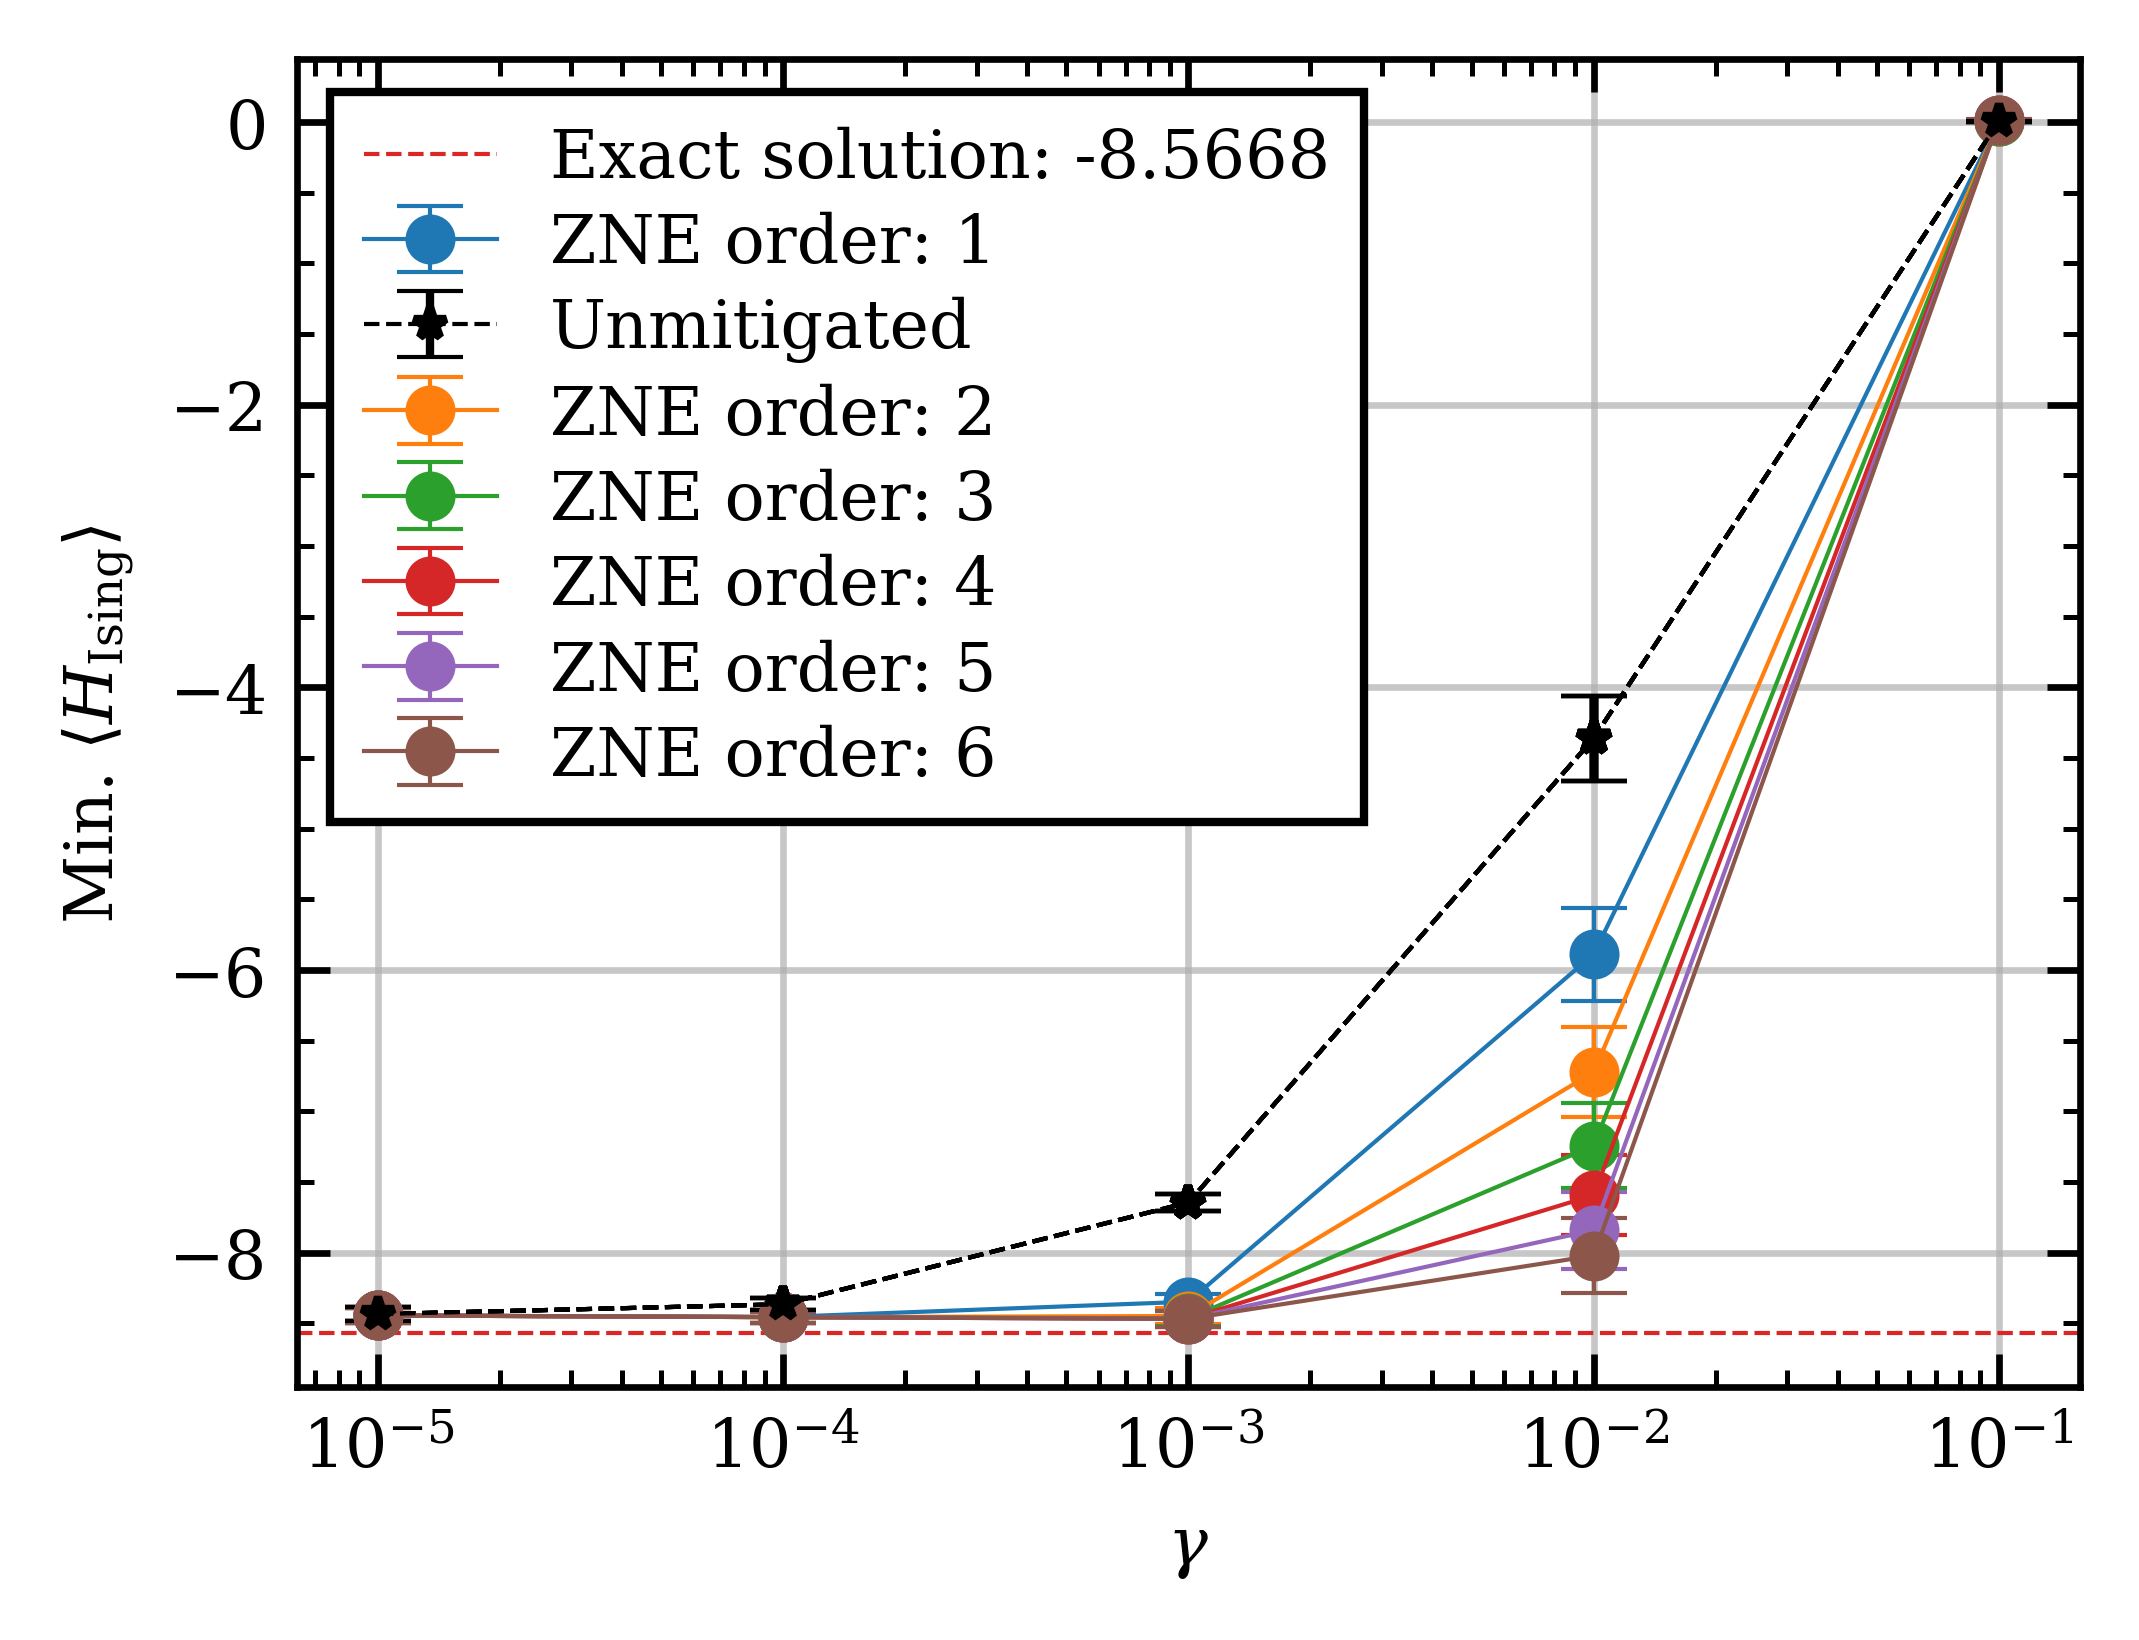

In [13]:
plot_zne_vs_delp(
    PROCESSED_SIM_DATA,
    rics=["ric1", "ric2", "ric3", "ric4", "ric5", "ric6"],
    #title="ZNE vs delp",
    file_name="RESULT-ZNE-VS-DELP-IEEE",
    figsize=FIG_SIZE_IEEE_DOUBLE,
    file_type="png",
    dpi=600,
    save_dir=MASTER_EXPORT_DIR,
    
)

In [ ]:
plot_zne_vs_delp(
    PROCESSED_SIM_DATA,
    rics=["ric2", "ric3", "ric4", "ric5", "ric6", "ric7"],
    #title="ZNE vs delp",
    file_name="RESULT-ZNE-VS-DELP-IEEE_SINGLE_COL",
    figsize=(3.25, 2.5),
    file_type="png",
    dpi=600,
    save_dir=MASTER_EXPORT_DIR,
    
)